In [1]:
import subprocess, sys

for pkg in ["openai", "sentence-transformers", "faiss-cpu", "tabulate", "tqdm", "scikit-learn", "matplotlib"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, sys

PROJECT_DIR = "/Users/macbookpro/Documents/Master-study/NLP/absa-vlsp2018-hotel"
os.chdir(PROJECT_DIR)
sys.path.insert(0, os.path.join(PROJECT_DIR, "code", "week3"))
sys.path.insert(0, os.path.join(PROJECT_DIR, "code", "week1"))

In [3]:
import pandas as pd

train_df = pd.read_csv("data/train_preprocessed.csv")
test_df  = pd.read_csv("data/test_preprocessed.csv")

In [4]:
OPENAI_API_KEY = "YOUR_OPENAI_API_KEY_HERE"

api_keys = {"openai": OPENAI_API_KEY}

In [6]:
from prompts import build_prompt, parse_llm_output
from llm_client import LLMClient
from icl_predictor import df_to_examples

client   = LLMClient(provider="openai", api_key=OPENAI_API_KEY)
sample   = test_df.iloc[0]["processed_review"]
examples = df_to_examples(train_df, [0, 1])
response = client.complete(build_prompt(sample, examples))
parse_llm_output(response)

{'ROOMS#CLEANLINESS': 'negative', 'SERVICE#GENERAL': 'negative'}

In [6]:
print("Câu mẫu (sample):", sample)
print("Ví dụ (examples):", examples)
print("Kết quả (response):", response)

Câu mẫu (sample): Ga giường không sạch , nhân_viên quên dọn phòng một ngày .
Ví dụ (examples): [{'review': 'Rộng_rãi khách_sạn mới nhưng rất vắng . Các dịch_vụ chất_lượng chưa cao và thiếu .', 'labels': {'HOTEL#DESIGN&FEATURES': 'positive', 'HOTEL#GENERAL': 'negative'}}, {'review': 'Địa_điểm thuận_tiện , trong vòng bán_kính 1,5 km nhiều quán ăn ngon', 'labels': {'LOCATION#GENERAL': 'positive'}}]
Kết quả (response): 1. Các từ/cụm từ quan trọng: "Ga giường không sạch", "nhân viên quên dọn phòng một ngày".
2. Xác định các aspect:
   - **ROOMS#CLEANLINESS**: Review đề cập đến ga giường không sạch → có.
   - **SERVICE#GENERAL**: Review đề cập đến nhân viên quên dọn phòng → có.
3. Xác định cảm xúc:
   - **ROOMS#CLEANLINESS**: negative (không sạch).
   - **SERVICE#GENERAL**: negative (quên dọn phòng).
4. Kết quả:

```json
{"ROOMS#CLEANLINESS": "negative", "SERVICE#GENERAL": "negative"}
```


In [7]:
from icl_predictor import run_icl_ablation

tier2_results = run_icl_ablation(
    test_df=test_df,
    train_df=train_df,
    providers=["openai"],
    k_values=[2, 4, 8],
    api_keys=api_keys,
    models={"openai": "gpt-4o-mini"},
    results_dir="outputs/results",
    max_samples=None,
    sleep_sec=1.0,
)


──────────────────────────────────────────────────
Running: tier2_openai_k2


ICL k=2:  39%|████████████████████████████████████████████▊                                                                     | 236/600 [26:42<50:39,  8.35s/it]

[WARN] Không tìm thấy JSON trong output: 1. Từ/cụm từ quan trọng: "Hồ bơi rộng rãi", "Bữa sáng đa dạng", "Mọi thứ đều tốt".
2. Xác định các a


ICL k=2:  49%|███████████████████████████████████████████████████████▋                                                          | 293/600 [33:01<32:11,  6.29s/it]

[WARN] Không tìm thấy JSON trong output: 1. Từ/cụm từ quan trọng: "Giường nệm rất thoải mái", "vị trí tiện di chuyển", "cách âm tốt hơn một c


...

[WARN] Không tìm thấy JSON trong output: 1. Từ/cụm từ quan trọng:
   - Nhân viên nhiệt tình, lịch sự
   - Giá cả tốt
   - Phòng sạch đẹp
   -


ICL k=8:  91%|█████████████████████████████████████████████████████████████████████████████████████████████████████▉          | 546/600 [1:04:42<05:51,  6.52s/it]

[WARN] Invalid aspect: SERVICE#MISCELLANEOUS


ICL k=8: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [1:11:14<00:00,  7.12s/it]


  Tầng 2 — openai k=8
Aspect                               ACD-F1    ACD-P     ACD-R     SPC-F1    Support
-----------------------------------  --------  --------  --------  --------  ---------
FACILITIES#CLEANLINESS               0.0000    0.0000    0.0000    0.0000    5
* FOOD&DRINKS#MISCELLANEOUS          0.0000    0.0000    0.0000    0.0000    3
HOTEL#MISCELLANEOUS                  0.0000    0.0000    0.0000    0.0000    68
* ROOMS#MISCELLANEOUS                0.0000    0.0000    0.0000    0.0000    4
* ROOM_AMENITIES#MISCELLANEOUS       0.0000    0.0000    0.0000    0.0000    3
* ROOM_AMENITIES#PRICES              0.0000    0.0000    0.0000    0.0000    1
ROOM_AMENITIES#COMFORT               0.0526    0.2500    0.0294    0.0451    68
FACILITIES#COMFORT                   0.0741    1.0000    0.0385    0.0000    26
FACILITIES#PRICES                    0.1053    0.1667    0.0769    0.0741    13
FACILITIES#DESIGN&FEATURES           0.1266    0.3571    0.0769    0.0775    65
FACILITIES

In [8]:
from rag_predictor import run_rag_ablation

tier3_results = run_rag_ablation(
    test_df=test_df,
    train_df=train_df,
    providers=["openai"],
    k_values=[2, 4, 8],
    api_keys=api_keys,
    models={"openai": "gpt-4o-mini"},
    results_dir="outputs/results",
    max_samples=None,
    sleep_sec=1.0,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Retriever] Loaded: keepitreal/vietnamese-sbert
[Retriever] Embedding 3000 train reviews...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

[Retriever] Saved embeddings: outputs/results/embeddings_cache.npy
[FAISS] Index built: 3000 vectors

──────────────────────────────────────────────────
Running: tier3_openai_k2


...

[WARN] Invalid aspect: VIEW#GENERAL


RAG k=4: 100%|████████████████████████████| 600/600 [1:06:01<00:00,  6.60s/it]



  Tầng 3 — openai k=4
Aspect                               ACD-F1    ACD-P     ACD-R     SPC-F1    Support
-----------------------------------  --------  --------  --------  --------  ---------
* FOOD&DRINKS#MISCELLANEOUS          0.0000    0.0000    0.0000    0.0000    3
* ROOMS#MISCELLANEOUS                0.0000    0.0000    0.0000    0.0000    4
* ROOM_AMENITIES#MISCELLANEOUS       0.0000    0.0000    0.0000    0.0000    3
* ROOM_AMENITIES#PRICES              0.0000    0.0000    0.0000    0.0000    1
HOTEL#MISCELLANEOUS                  0.0800    0.4286    0.0441    0.0360    68
ROOM_AMENITIES#COMFORT               0.1096    0.8000    0.0588    0.0981    68
FACILITIES#DESIGN&FEATURES           0.1538    0.4615    0.0923    0.1288    65
FACILITIES#CLEANLINESS               0.1818    0.1667    0.2000    0.1667    5
FACILITIES#COMFORT                   0.1875    0.5000    0.1154    0.0580    26
ROOMS#GENERAL                        0.1913    0.1897    0.1930    0.3089    57
ROOMS#QUAL

RAG k=8: 100%|████████████████████████████| 600/600 [1:05:18<00:00,  6.53s/it]


  Tầng 3 — openai k=8
Aspect                               ACD-F1    ACD-P     ACD-R     SPC-F1    Support
-----------------------------------  --------  --------  --------  --------  ---------
* FOOD&DRINKS#MISCELLANEOUS          0.0000    0.0000    0.0000    0.0000    3
* ROOMS#MISCELLANEOUS                0.0000    0.0000    0.0000    0.0000    4
* ROOM_AMENITIES#MISCELLANEOUS       0.0000    0.0000    0.0000    0.0000    3
* ROOM_AMENITIES#PRICES              0.0000    0.0000    0.0000    0.0000    1
HOTEL#MISCELLANEOUS                  0.0571    1.0000    0.0294    0.0370    68
FACILITIES#CLEANLINESS               0.1333    0.1000    0.2000    0.1667    5
FACILITIES#COMFORT                   0.1333    0.5000    0.0769    0.1270    26
ROOM_AMENITIES#COMFORT               0.1500    0.5000    0.0882    0.1357    68
ROOM_AMENITIES#GENERAL               0.1887    0.1351    0.3125    0.1626    32
* FACILITIES#MISCELLANEOUS           0.2069    0.1429    0.3750    0.2500    8
ROOMS#GENER

In [9]:
from compare_results import generate_comparison_table

print(generate_comparison_table(
    results_dir="outputs/results",
    save_path="outputs/results/week3_comparison.md",
))

[Report] Saved: outputs/results/week3_comparison.md
# Bảng So sánh Kết quả — ABSA VLSP 2018 Hotel

| Tầng     | Phương pháp   | k   |   ACD F1 | SPC F1   |   Combined F1 |
|:---------|:--------------|:----|---------:|:---------|--------------:|
| SOTA     | PhoBERT       | —   |   0.8255 | —        |        0.7732 |
| Tầng 1   | PhoBERT       | —   |   0.636  | 0.4727   |        0.5543 |
| Tầng 1   | PhoBERT       | —   |   0.5836 | 0.4658   |        0.5247 |
| Tầng 3   | GPT-4o-mini   | 8   |   0.4034 | 0.3031   |        0.3532 |
| Tầng 3   | GPT-4o-mini   | 16  |   0.3988 | 0.2879   |        0.3433 |
| Tầng 3   | GPT-4o-mini   | 4   |   0.3866 | 0.2883   |        0.3375 |
| Tầng 3   | GPT-4o-mini   | 2   |   0.3793 | 0.2866   |        0.333  |
| Baseline | SVM+TF-IDF    | —   |   0.4074 | 0.2272   |        0.3173 |
| Tầng 2   | GPT-4o-mini   | 8   |   0.3504 | 0.2567   |        0.3035 |
| Tầng 2   | GPT-4o-mini   | 2   |   0.3342 | 0.2656   |        0.2999 |
| Tầng 2   | GPT-4o-mini 

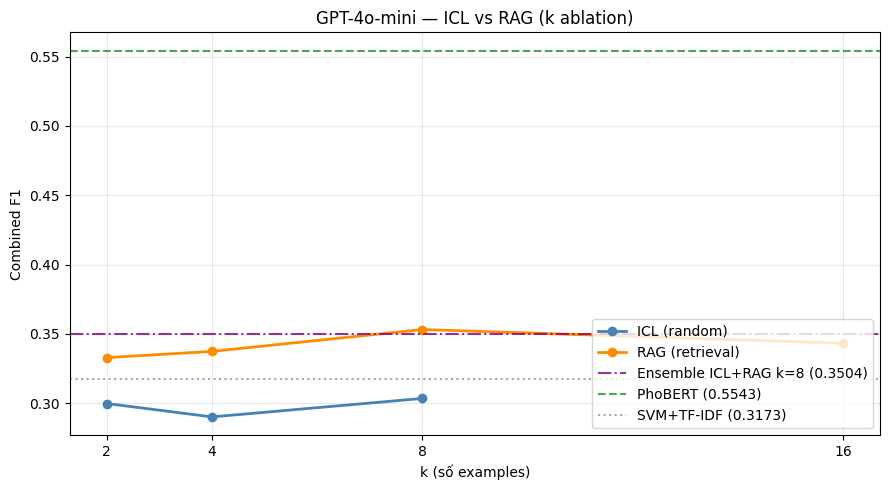

Saved: outputs/eda/week3_ablation.png


In [10]:
import json, os, matplotlib.pyplot as plt

provider = "openai"
PHOBERT_F1 = 0.5543
SVM_F1     = 0.3173

# Load ICL và RAG — tự động include k=16 nếu file đã có
k_values = [2, 4, 8]
if os.path.exists(f"outputs/results/tier3_{provider}_k16_metrics.json"):
    k_values = [2, 4, 8, 16]

icl_f1s, rag_f1s = [], []
for k in k_values:
    icl_path = f"outputs/results/tier2_{provider}_k{k}_metrics.json"
    rag_path  = f"outputs/results/tier3_{provider}_k{k}_metrics.json"
    if os.path.exists(icl_path):
        icl_f1s.append(json.load(open(icl_path))["macro_combined_f1"])
    if os.path.exists(rag_path):
        rag_f1s.append(json.load(open(rag_path))["macro_combined_f1"])

# Load ensemble nếu có
ensemble_f1 = None
ens_path = "outputs/results/ensemble_icl_rag_k8_metrics.json"
if os.path.exists(ens_path):
    ensemble_f1 = json.load(open(ens_path))["macro_combined_f1"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values[:len(icl_f1s)], icl_f1s, "o-", color="steelblue",  label="ICL (random)",    lw=2)
ax.plot(k_values[:len(rag_f1s)], rag_f1s, "o-", color="darkorange", label="RAG (retrieval)", lw=2)

if ensemble_f1 is not None:
    ax.axhline(y=ensemble_f1, color="purple", ls="-.",
               label=f"Ensemble ICL+RAG k=8 ({ensemble_f1:.4f})", alpha=0.8)

ax.axhline(y=PHOBERT_F1, color="green", ls="--", label=f"PhoBERT ({PHOBERT_F1:.4f})", alpha=0.7)
ax.axhline(y=SVM_F1,     color="gray",  ls=":",  label=f"SVM+TF-IDF ({SVM_F1:.4f})", alpha=0.7)

ax.set(title="GPT-4o-mini — ICL vs RAG (k ablation)",
       xlabel="k (số examples)", ylabel="Combined F1")
ax.set_xticks(k_values)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/eda/week3_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/eda/week3_ablation.png")

# Option 1 — Ensemble ICL k=8 + RAG k=8
> **Không tốn API.** Re-run cả 2 để lấy y_pred (load từ cache), sau đó vote: nếu ICL và RAG đồng ý → dùng, nếu bất đồng → tin RAG.

In [7]:
import numpy as np
import importlib
import prompts as _prompts_mod; importlib.reload(_prompts_mod)  # đảm bảo dùng prompts mới nhất

from icl_predictor import predict_icl
from rag_predictor import predict_rag
from rag_retriever import ABSARetriever
from llm_client import LLMClient
from step4_eval import evaluate_predictions

client_ens = LLMClient(provider="openai", api_key=OPENAI_API_KEY, model="gpt-4o-mini")

# ── Re-run ICL k=8 (load từ cache, không gọi API) ──────────────────────────
print("Re-running ICL k=8 từ cache...")
y_true_icl8, y_pred_icl8 = predict_icl(
    test_df, train_df, client_ens,
    k=8, seed=42, max_samples=None,
    sleep_sec=0,  # cache hit → không cần sleep
)
print(f"ICL k=8 done: {y_pred_icl8.shape}")

# ── Re-run RAG k=8 (load từ cache, không gọi API) ──────────────────────────
print("\nRe-running RAG k=8 từ cache...")
retriever_ens = ABSARetriever()
retriever_ens.fit(train_df)  # load từ embeddings_cache.npy
y_true_rag8, y_pred_rag8 = predict_rag(
    test_df, train_df, client_ens, retriever_ens,
    k=8, max_samples=None,
    sleep_sec=0,
)
print(f"RAG k=8 done: {y_pred_rag8.shape}")

# ── Ensemble: bất đồng → tin RAG ───────────────────────────────────────────
y_pred_ensemble = np.where(y_pred_icl8 == y_pred_rag8, y_pred_icl8, y_pred_rag8)

agree_rate = (y_pred_icl8 == y_pred_rag8).mean()
print(f"\nTỷ lệ ICL và RAG đồng ý: {agree_rate:.1%}")

metrics_ens = evaluate_predictions(
    y_true_rag8, y_pred_ensemble,
    title="Ensemble ICL+RAG k=8",
    save_path="outputs/results/ensemble_icl_rag_k8_metrics.json",
)
print(f"\n{'='*40}")
print(f"Ensemble Combined F1 : {metrics_ens['macro_combined_f1']:.4f}")
print(f"RAG k=8 (best trước) : 0.3532")
print(f"Thay đổi             : {(metrics_ens['macro_combined_f1'] - 0.3532)*100:+.2f}%")

Re-running ICL k=8 từ cache...


ICL k=8:  14%|███████▌                                             | 86/600 [00:00<00:00, 854.68it/s]

[WARN] Không tìm thấy JSON trong output: 1. Từ/cụm từ quan trọng:
   - Trang thiết bị trong phòng hiện đại
   - Phòng trên các tầng cao view 
[WARN] Invalid aspect: SERVICE#MISCELLANEOUS
[WARN] Invalid aspect: SERVICE#PRICES


ICL k=8: 100%|█████████████████████████████████████████████████████| 600/600 [41:16<00:00,  4.13s/it]


ICL k=8 done: (600, 34)

Re-running RAG k=8 từ cache...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Retriever] Loaded: keepitreal/vietnamese-sbert
[Retriever] Loaded embeddings cache: (3000, 768)


RAG k=8: 100%|████████████████████████████████████████████████████████████████| 600/600 [00:57<00:00, 10.49it/s]


RAG k=8 done: (600, 34)

Tỷ lệ ICL và RAG đồng ý: 94.6%

  Ensemble ICL+RAG k=8
Aspect                               ACD-F1    ACD-P     ACD-R     SPC-F1    Support
-----------------------------------  --------  --------  --------  --------  ---------
* FOOD&DRINKS#MISCELLANEOUS          0.0000    0.0000    0.0000    0.0000    3
* ROOMS#MISCELLANEOUS                0.0000    0.0000    0.0000    0.0000    4
* ROOM_AMENITIES#MISCELLANEOUS       0.0000    0.0000    0.0000    0.0000    3
* ROOM_AMENITIES#PRICES              0.0000    0.0000    0.0000    0.0000    1
HOTEL#MISCELLANEOUS                  0.0571    1.0000    0.0294    0.0370    68
FACILITIES#CLEANLINESS               0.1333    0.1000    0.2000    0.1667    5
FACILITIES#COMFORT                   0.1333    0.5000    0.0769    0.1270    26
ROOM_AMENITIES#COMFORT               0.1500    0.5000    0.0882    0.1357    68
ROOM_AMENITIES#GENERAL               0.1905    0.1370    0.3125    0.1626    32
* FACILITIES#MISCELLANEOUS       

# Option 2 — RAG k=16
> **Tốn ~$0.05–0.08.** Kiểm tra xem trend RAG có tiếp tục tăng khi k lớn hơn không. k=16 < candidate_pool=50 nên aspect-aware selection vẫn hoạt động bình thường.

In [8]:
from rag_predictor import run_rag_ablation

tier3_k16_results = run_rag_ablation(
    test_df=test_df,
    train_df=train_df,
    providers=["openai"],
    k_values=[16],
    api_keys=api_keys,
    models={"openai": "gpt-4o-mini"},
    results_dir="outputs/results",
    max_samples=None,
    sleep_sec=1.0,
)

rag_k8_f1  = 0.3532
rag_k16_f1 = tier3_k16_results["tier3_openai_k16"]["macro_combined_f1"]

print(f"\n{'='*40}")
print(f"RAG k=8  Combined F1 : 0.3532")
print(f"RAG k=16 Combined F1 : {rag_k16_f1:.4f}")
print(f"Thay đổi             : {(rag_k16_f1 - rag_k8_f1)*100:+.2f}%")
print()
if rag_k16_f1 > rag_k8_f1:
    print("✅ Trend tiếp tục tăng — k lớn hơn vẫn giúp ích")
else:
    print("⚠️  Saturation — k=8 đã là điểm tối ưu cho RAG")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Retriever] Loaded: keepitreal/vietnamese-sbert
[Retriever] Loaded embeddings cache: (3000, 768)

──────────────────────────────────────────────────
Running: tier3_openai_k16


RAG k=16:   9%|█████▌                                                        | 54/600 [09:58<1:33:12, 10.24s/it]

[WARN] Invalid aspect: FACILITIES#STYLE&OPTIONS


RAG k=16:  62%|██████████████████████████████████████                       | 374/600 [1:01:24<41:56, 11.13s/it]

[RETRY] Attempt 1 failed: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}. Waiting 5.0s...


RAG k=16: 100%|█████████████████████████████████████████████████████████████| 600/600 [1:34:55<00:00,  9.49s/it]


  Tầng 3 — openai k=16
Aspect                               ACD-F1    ACD-P     ACD-R     SPC-F1    Support
-----------------------------------  --------  --------  --------  --------  ---------
FACILITIES#COMFORT                   0.0000    0.0000    0.0000    0.0000    26
* FOOD&DRINKS#MISCELLANEOUS          0.0000    0.0000    0.0000    0.0000    3
* ROOMS#MISCELLANEOUS                0.0000    0.0000    0.0000    0.0000    4
* ROOM_AMENITIES#MISCELLANEOUS       0.0000    0.0000    0.0000    0.0000    3
* ROOM_AMENITIES#PRICES              0.0000    0.0000    0.0000    0.0000    1
HOTEL#MISCELLANEOUS                  0.0556    0.5000    0.0294    0.0370    68
* FACILITIES#MISCELLANEOUS           0.0952    0.0769    0.1250    0.1111    8
FACILITIES#CLEANLINESS               0.1429    0.1111    0.2000    0.1667    5
ROOMS#GENERAL                        0.1818    0.2143    0.1579    0.2974    57
FACILITIES#GENERAL                   0.2000    0.1538    0.2857    0.1600    21
ROOM_AMENI